In [7]:
import numpy as np
#create a copy of the data
df_raw = pd.read_csv("Unstructured _Data.csv")

df = df_raw.copy()

In [8]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hotel Name         1780 non-null   object 
 1   Price (SAR)        965 non-null    object 
 2   Rating             1688 non-null   float64
 3   Reviews            1688 non-null   float64
 4   Address            1780 non-null   object 
 5   City               1780 non-null   object 
 6   Check-in           1780 non-null   object 
 7   Check-out          1780 non-null   object 
 8   Search Area        1780 non-null   object 
 9   Season_Type        1780 non-null   object 
 10  Religious_Context  1780 non-null   object 
dtypes: float64(2), object(9)
memory usage: 153.1+ KB


,Rating,Reviews
count,1688.000000,1688.000000
mean,4.108359,3649.544431
std,0.458389,9493.631574
min,2.000000,2.000000
25%,3.800000,156.000000
50%,4.100000,590.000000
75%,4.450000,1974.000000
max,5.000000,116749.000000


# **Data Cleaning**

In [9]:
# Calculate missing values percentage
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

missing_table.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
Price (SAR),815,45.786517
Rating,92,5.168539
Reviews,92,5.168539
Hotel Name,0,0.000000
Address,0,0.000000
City,0,0.000000
Check-in,0,0.000000
Check-out,0,0.000000
Search Area,0,0.000000
Season_Type,0,0.000000


In [10]:
# Remove duplicates based on specific booking details (Address, Check-in, Check-out) rather than just the hotel name
duplicate_count = df.duplicated(subset=['Address', 'Check-in', 'Check-out']).sum()
print(f"Number of duplicates found: {duplicate_count}")

df.drop_duplicates(subset=['Address', 'Check-in', 'Check-out'], inplace=True)
df.drop_duplicates(inplace=True)


print(df.shape)

Number of duplicates found: 5
(1775, 11)


In [11]:
import re
# Clean the Price column: convert Arabic numerals to English and extract only digits

def arabic_to_english_number(text):
    arabic_numbers = "٠١٢٣٤٥٦٧٨٩"
    english_numbers = "0123456789"
    translator = str.maketrans(arabic_numbers, english_numbers)
    return text.translate(translator)

def clean_price(value):
    if pd.isna(value):
        return None
    value = str(value)
    value = arabic_to_english_number(value)
    value = re.sub(r"[^\d]", "", value)
    if value == "":
        return None
    return float(value)

df["Price (SAR)"] = df["Price (SAR)"].apply(clean_price)

print(df["Price (SAR)"])

0       268.0
1       217.0
2       193.0
3       227.0
4       279.0
        ...  
1775      NaN
1776      NaN
1777      NaN
1778      NaN
1779      NaN
Name: Price (SAR), Length: 1775, dtype: float64


In [12]:
# Impute missing values:
# - Median for Price
# - Mean for Rating
# - 0 for Reviews

df["Price (SAR)"] = df["Price (SAR)"].fillna(df["Price (SAR)"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].mean()).round(1)
df["Reviews"] = df["Reviews"].fillna(0)

print(df.isnull().sum())

Hotel Name           0
Price (SAR)          0
Rating               0
Reviews              0
Address              0
City                 0
Check-in             0
Check-out            0
Search Area          0
Season_Type          0
Religious_Context    0
dtype: int64


In [13]:
# Extract Latitude and Longitude from the Address string

df[["Latitude", "Longitude"]] = df["Address"].str.extract(r"Lat:\s*(-?[\d\.]+),\s*Lng:\s*(-?[\d\.]+)")

df["Latitude"] = pd.to_numeric(df["Latitude"])
df["Longitude"] = pd.to_numeric(df["Longitude"])

print(df[["Address", "Latitude", "Longitude"]].head())

                                    Address   Latitude  Longitude
0  Lat: 21.3803482, Lng: 39.874021299999995  21.380348  39.874021
1  Lat: 21.445215500000003, Lng: 39.8343673  21.445216  39.834367
2          Lat: 21.4708984, Lng: 39.8434205  21.470898  39.843421
3           Lat: 21.4163086, Lng: 39.860443  21.416309  39.860443
4          Lat: 21.3808384, Lng: 39.8727707  21.380838  39.872771


In [14]:
# Standardize date columns to datetime objects
df["Check-in"] = pd.to_datetime(df["Check-in"])
df["Check-out"] = pd.to_datetime(df["Check-out"])
print(df[["Check-in", "Check-out"]])

       Check-in  Check-out
0    2026-02-15 2026-02-20
1    2026-02-15 2026-02-20
2    2026-02-15 2026-02-20
3    2026-02-15 2026-02-20
4    2026-02-15 2026-02-20
...         ...        ...
1775 2026-07-01 2026-07-06
1776 2026-07-01 2026-07-06
1777 2026-07-01 2026-07-06
1778 2026-07-01 2026-07-06
1779 2026-07-01 2026-07-06

[1775 rows x 2 columns]


In [15]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 1775 entries, 0 to 1779
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Hotel Name         1775 non-null   object        
 1   Price (SAR)        1775 non-null   float64       
 2   Rating             1775 non-null   float64       
 3   Reviews            1775 non-null   float64       
 4   Address            1775 non-null   object        
 5   City               1775 non-null   object        
 6   Check-in           1775 non-null   datetime64[ns]
 7   Check-out          1775 non-null   datetime64[ns]
 8   Search Area        1775 non-null   object        
 9   Season_Type        1775 non-null   object        
 10  Religious_Context  1775 non-null   object        
 11  Latitude           1775 non-null   float64       
 12  Longitude          1775 non-null   float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memory usage: 194.1+ KB


,0
Hotel Name,0
Price (SAR),0
Rating,0
Reviews,0
Address,0
City,0
Check-in,0
Check-out,0
Search Area,0
Season_Type,0


In [16]:
df.to_csv("CLEANED_HAJJ_UMRAH.csv", index=False)

# **Data Preprocessing**

In [17]:
# Create duration of stay
df["Stay_Duration"] = (df["Check-out"] - df["Check-in"]).dt.days

# Create a Price category
df["Price_Category"] = pd.cut(
    df["Price (SAR)"],
    bins=[0, 300, 800, 1500, 10000],
    labels=["Budget", "Mid-Range", "Premium", "Luxury"]
)

In [18]:
# One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=["City", "Season_Type", "Price_Category"],
    drop_first=False
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_features = ["Price (SAR)", "Rating", "Reviews", "Stay_Duration"]

df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

In [20]:
df_encoded.to_csv("PROCESSED_HAJJ_UMRAH_2026.csv", index=False)

# **EDA**

In [21]:
import numpy as np
import pandas as pd
#create a copy of the data
df_raw = pd.read_csv("PROCESSED_HAJJ_UMRAH_2026.csv")

df = df_raw.copy()


In [22]:
df["Price (SAR)"] = pd.to_numeric(df["Price (SAR)"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")


In [23]:
df[["Price (SAR)", "Rating"]].describe()

,Price (SAR),Rating
count,1.775000e+03,1.775000e+03
mean,4.403363e-17,8.366391e-16
std,1.000282e+00,1.000282e+00
min,-3.021553e-01,-4.741703e+00
25%,-1.046732e-01,-6.962702e-01
50%,-9.095919e-02,-2.203146e-02
75%,-7.073099e-02,6.522073e-01
max,4.006853e+01,2.000685e+00


Generated descriptive statistics for Price and Rating.
The mean is approximately 0 and the standard deviation is close to 1,
 confirming successful standardization.
 The maximum price value is significantly higher than the rest,
indicating the presence of an extreme price outlier.

In [24]:
df[["City_Makkah","City_Madinah","City_Taif"]].sum()


,0
City_Makkah,921
City_Madinah,448
City_Taif,406


Makkah contains the highest number of hotels, followed by Madinah, while Taif has the lowest number.
This suggests that hotel supply is concentrated in Makkah, likely due to higher demand.

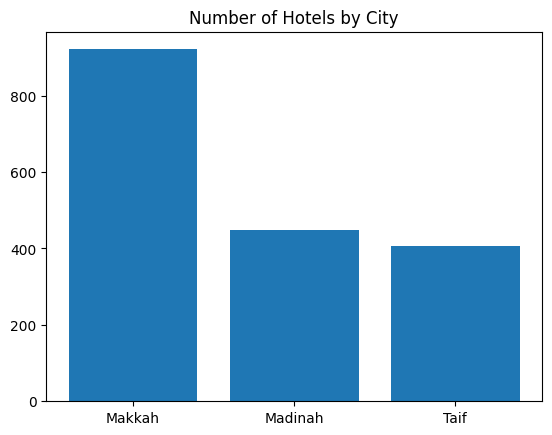

In [25]:
import matplotlib.pyplot as plt
plt.figure()
city_counts = df[["City_Makkah","City_Madinah","City_Taif"]].sum()
plt.bar(["Makkah","Madinah","Taif"], city_counts)
plt.title("Number of Hotels by City")
plt.show()


The visualization clearly shows that Makkah dominates in hotel availability,
indicating it is the primary destination among the three cities.

In [26]:
df[[
    "Season_Type_Hajj Peak",
    "Season_Type_Pre-Hajj",
    "Season_Type_Ramadan Season",
    "Season_Type_Regular Umrah"
]].sum()


,0
Season_Type_Hajj Peak,296
Season_Type_Pre-Hajj,292
Season_Type_Ramadan Season,592
Season_Type_Regular Umrah,595


Ramadan season has the highest number of hotels, while other seasons are relatively similar in distribution.
This suggests that Ramadan is a peak operational period.

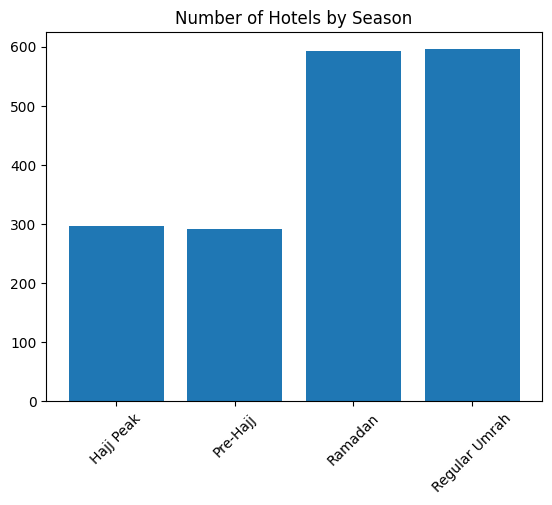

In [27]:
plt.figure()
season_counts = df[
    ["Season_Type_Hajj Peak",
     "Season_Type_Pre-Hajj",
     "Season_Type_Ramadan Season",
     "Season_Type_Regular Umrah"]
].sum()

plt.bar(["Hajj Peak","Pre-Hajj","Ramadan","Regular Umrah"], season_counts)
plt.xticks(rotation=45)
plt.title("Number of Hotels by Season")
plt.show()


The bar chart confirms that hotel availability increases during Ramadan,
indicating higher demand compared to other seasons.

In [28]:
df[["Price (SAR)", "Rating"]].corr()


,Price (SAR),Rating
Price (SAR),1.000000,0.033561
Rating,0.033561,1.000000


There is almost no correlation between price and rating,
indicating that higher-priced hotels do not necessarily receive better ratings.

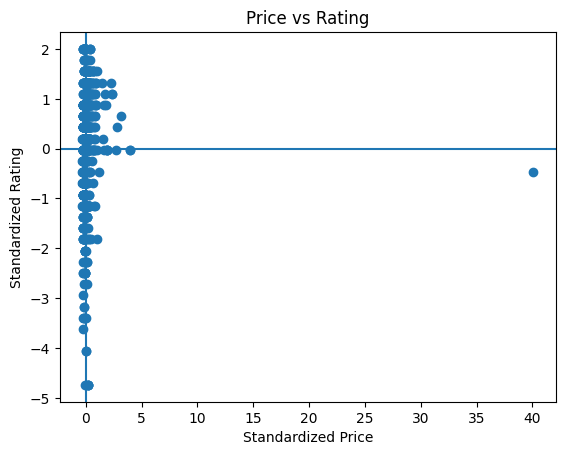

In [29]:
plt.figure()
plt.scatter(df["Price (SAR)"], df["Rating"])
plt.title("Price vs Rating")
plt.xlabel("Standardized Price")
plt.ylabel("Standardized Rating")
plt.axhline(0)
plt.axvline(0)
plt.show()


The scatter plot shows no clear linear relationship between price and rating.
Most data points cluster around average values, with a noticeable outlier at a very high price.

In [30]:
summary = pd.DataFrame({
    "City": ["Makkah", "Madinah", "Taif"],
    "Avg_Price": [
        df[df["City_Makkah"] == 1]["Price (SAR)"].mean(),
        df[df["City_Madinah"] == 1]["Price (SAR)"].mean(),
        df[df["City_Taif"] == 1]["Price (SAR)"].mean()
    ],
    "Avg_Rating": [
        df[df["City_Makkah"] == 1]["Rating"].mean(),
        df[df["City_Madinah"] == 1]["Rating"].mean(),
        df[df["City_Taif"] == 1]["Rating"].mean()
    ]
})

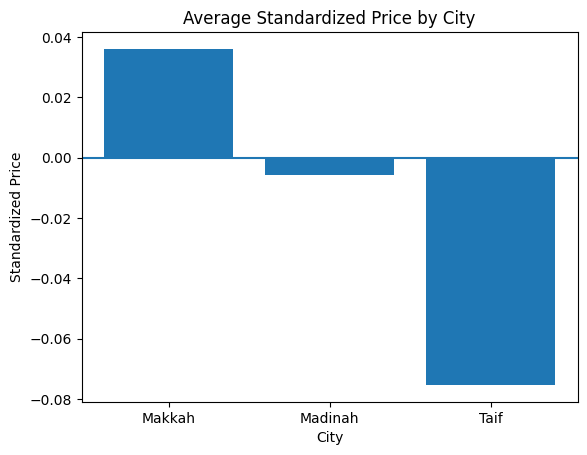

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(summary["City"], summary["Avg_Price"])
plt.title("Average Standardized Price by City")
plt.xlabel("City")
plt.ylabel("Standardized Price")
plt.axhline(0)
plt.show()


Makkah has the highest average standardized price, while Taif has the lowest.
This indicates that hotels in Makkah tend to be more expensive on average.

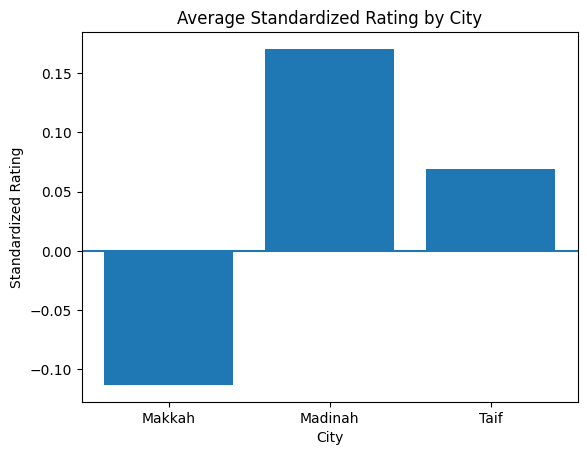

In [32]:
plt.figure()
plt.bar(summary["City"], summary["Avg_Rating"])
plt.title("Average Standardized Rating by City")
plt.xlabel("City")
plt.ylabel("Standardized Rating")
plt.axhline(0)
plt.show()


Madinah has the highest average rating
followed by Taif, while Makkah has the lowest average rating among the three cities.

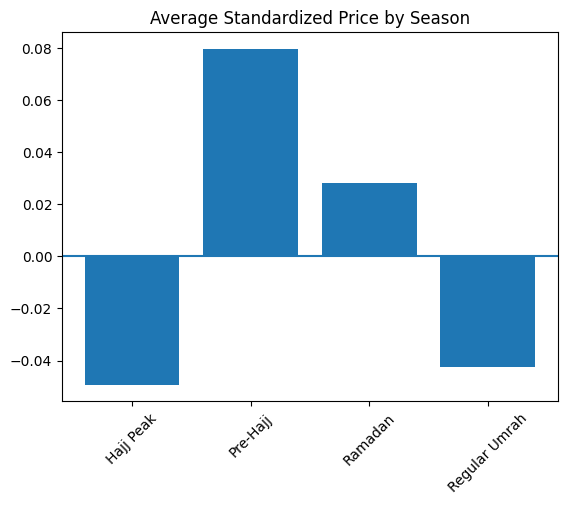

In [33]:
season_price = pd.DataFrame({
    "Season": ["Hajj Peak", "Pre-Hajj", "Ramadan", "Regular Umrah"],
    "Avg_Price": [
        df[df["Season_Type_Hajj Peak"] == 1]["Price (SAR)"].mean(),
        df[df["Season_Type_Pre-Hajj"] == 1]["Price (SAR)"].mean(),
        df[df["Season_Type_Ramadan Season"] == 1]["Price (SAR)"].mean(),
        df[df["Season_Type_Regular Umrah"] == 1]["Price (SAR)"].mean()
    ]
})

plt.figure()
plt.bar(season_price["Season"], season_price["Avg_Price"])
plt.title("Average Standardized Price by Season")
plt.xticks(rotation=45)
plt.axhline(0)
plt.show()


The bar chart shows the average standardized hotel price across different seasons.
Pre-Hajj has the highest average price, followed by Ramadan.
Hajj Peak and Regular Umrah show lower average prices.
This indicates that price increases tend to occur before the peak pilgrimage period.

# Secondary EDA

In [48]:
import pandas as pd

secondary_df = pd.read_csv("hotel_bookings.csv")

secondary_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [35]:
secondary_df.info();
secondary_df.describe();


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

The secondary dataset contains hotel booking records from an external source dataset.

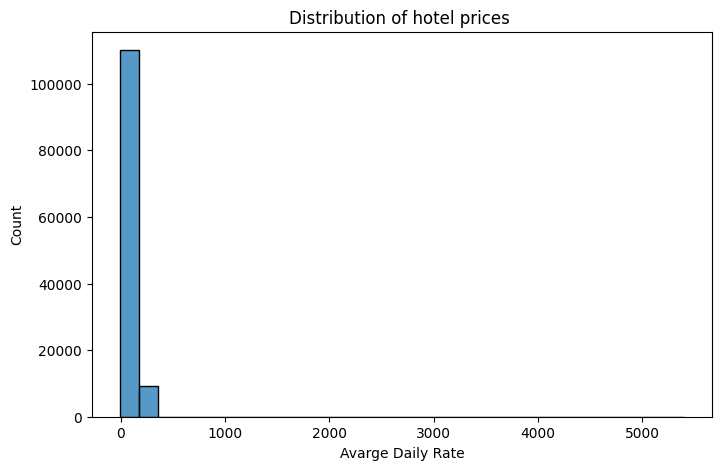

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(secondary_df['adr'], bins=30)
plt.title("Distribution of hotel prices ")
plt.xlabel("Avarge Daily Rate")
plt.show()

This histogram shows the distribution of hotel prices in the secondary dataset.


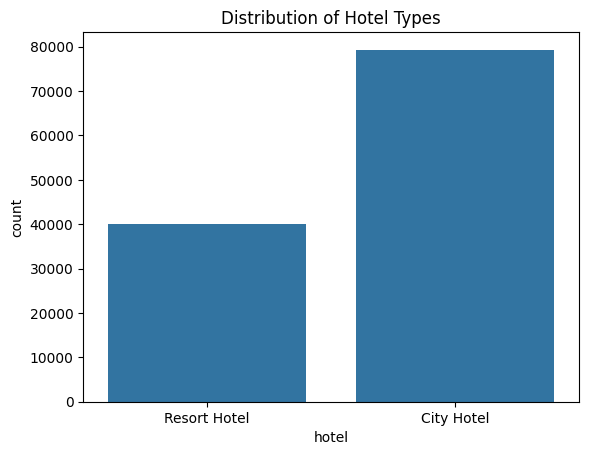

In [37]:
sns.countplot(x='hotel', data=secondary_df)
plt.title("Distribution of Hotel Types")
plt.show()

This chart shows the distribution of hotel types in the dataset, including Resort Hotels and City Hotels.

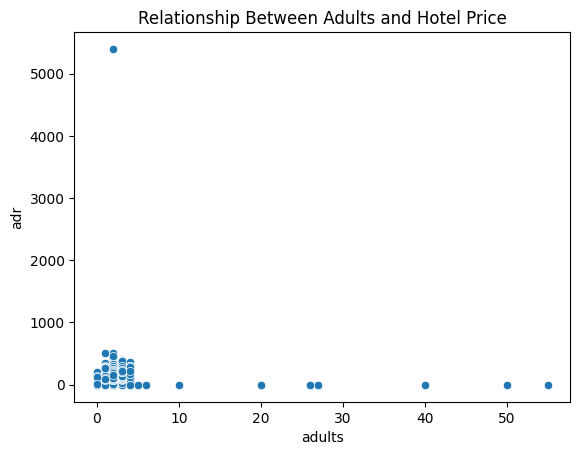

In [38]:
sns.scatterplot(x='adults', y='adr', data=secondary_df)
plt.title("Relationship Between Adults and Hotel Price")
plt.show()

The scatter plot explores whether the number of adults influences hotel prices.

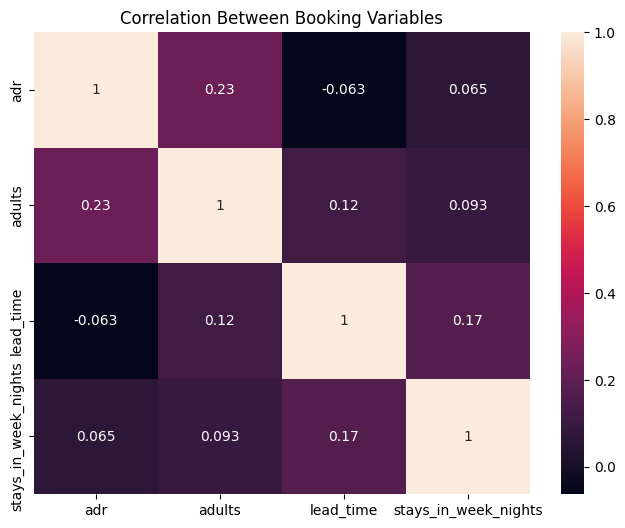

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(secondary_df[['adr','adults','lead_time','stays_in_week_nights']].corr(), annot=True)
plt.title("Correlation Between Booking Variables")
plt.show()

The correlation matrix highlights relationships between booking features and hotel pricing.

The secondary dataset comes from an external hotel booking dataset used in research.
It includes information about hotel type, price (ADR), and customer booking details.
This data helps provide additional insight into hotel pricing patterns.

Limitations:

The dataset is not specific to religious tourism.

Data may come from different countries and time periods.

Booking patterns may differ from Hajj and Umrah travel behavior.

## Compare Results of Datasets

firts, we run descriptive statistics for numerical variables in the secondary dataset, such as lead time, number of adults, waiting days, and ADR (Average Daily Rate).



In [40]:
secondary_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


then we compare the average hotel price in the primary dataset with the average daily rate (ADR) from the secondary dataset.


In [58]:
primary_df=pd.read_csv("CLEANED_HAJJ_UMRAH.csv")
primary_df["Price (SAR)"] = pd.to_numeric(primary_df["Price (SAR)"], errors="coerce")

In [59]:
import pandas as pd

price_comparison = pd.DataFrame({
    "Dataset": ["Primary Dataset", "Secondary Dataset"],
    "Average Price": [
       primary_df["Price (SAR)"].mean(),
        secondary_df["adr"].mean()
    ]
})

print(price_comparison)

             Dataset  Average Price
0    Primary Dataset     503.651268
1  Secondary Dataset     101.831122


### Average price comparison chart

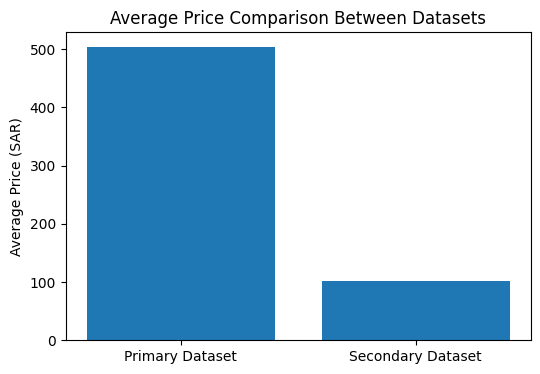

In [63]:
import matplotlib.pyplot as plt

primary_price = primary_df["Price (SAR)"].mean()
secondary_price = secondary_df["adr"].mean()

datasets = ["Primary Dataset", "Secondary Dataset"]
prices = [primary_price, secondary_price]

plt.figure(figsize=(6,4))

plt.bar(datasets, prices)

plt.title("Average Price Comparison Between Datasets")
plt.ylabel("Average Price (SAR)")

plt.show()

**Primary Dataset Price Distribution**

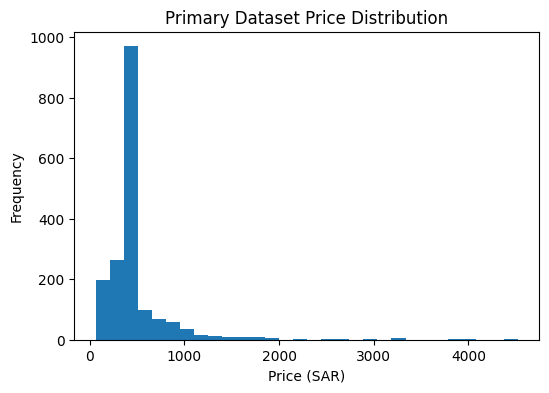

In [66]:
plt.figure(figsize=(6,4))

primary_prices = primary_df["Price (SAR)"]
primary_prices = primary_prices[primary_prices < 5000]  # لقيم المتطرفة

plt.hist(primary_prices, bins=30)

plt.title("Primary Dataset Price Distribution")
plt.xlabel("Price (SAR)")
plt.ylabel("Frequency")

plt.show()

**Secondary Dataset ADR Distribution**

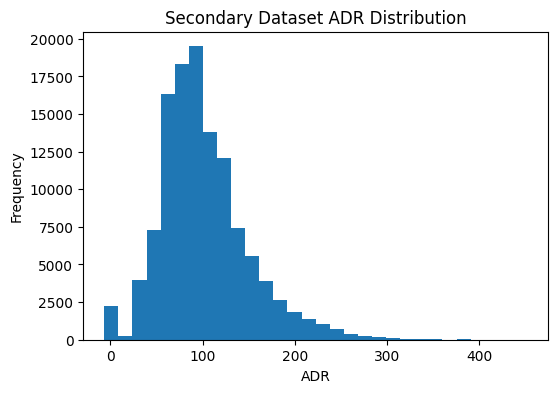

In [67]:
plt.figure(figsize=(6,4))

secondary_prices = secondary_df["adr"]
secondary_prices = secondary_prices[secondary_prices < 500]
plt.hist(secondary_prices, bins=30)

plt.title("Secondary Dataset ADR Distribution")
plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

#Primary Data Insights


Rating Distribution

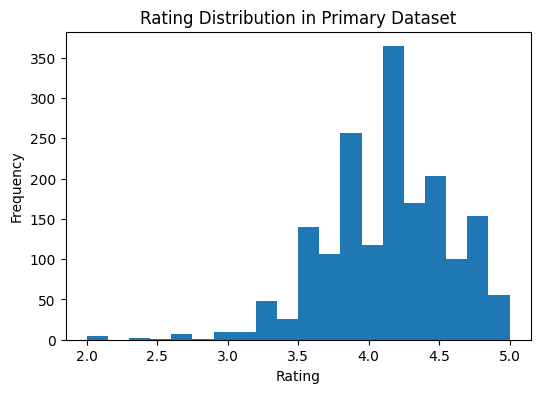

In [73]:
plt.figure(figsize=(6,4))

plt.hist(primary_df["Rating"], bins=20)

plt.title("Rating Distribution in Primary Dataset")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

Reviews distribution


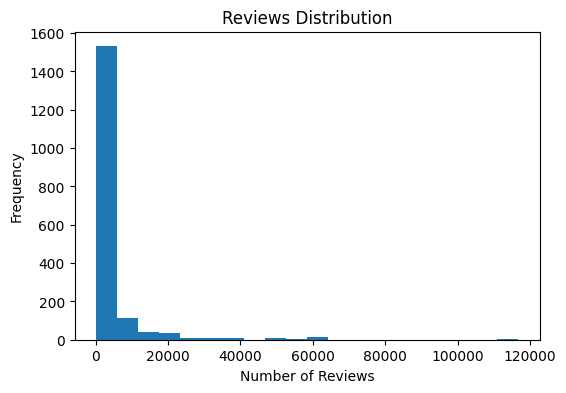

In [74]:
plt.figure(figsize=(6,4))

plt.hist(primary_df["Reviews"], bins=20)

plt.title("Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")

plt.show()

# Secondary Data Insights


Lead Time Distribution:
its how many days in advance a booking was made before the arrival date.


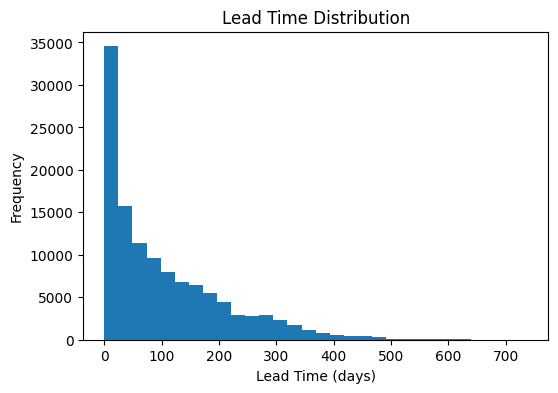

In [75]:
plt.figure(figsize=(6,4))

plt.hist(secondary_df["lead_time"], bins=30)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (days)")
plt.ylabel("Frequency")

plt.show()

Cancellation rate


In [76]:
cancel_rate = secondary_df["is_canceled"].mean()

print("Cancellation Rate:", cancel_rate)

Cancellation Rate: 0.37041628277075134
